In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
os.chdir(r"C:\Users\yhy_s\Desktop\DSC106\project-2\persuasive_deceptive_climate_change\data")
df = pd.read_excel("GuttmacherInstituteAbortionDataByState.xlsx")

df.head()

,U.S. State,"% change in abortion rate, 2017-2020","% change in the no. of abortion clinics, 2017-2020","% change in the no. of abortion providers, 2014-2017","% of all U.S. abortions, by state of occurrence, 2020","% of counties without a known abortion provider, 2014","% of counties without a known clinic, 2020","% of residents obtaining abortions who traveled out of state for care, 2020","% of women aged 15-44 living in a county without a clinic, 2020","% of women aged 15-44 living in a county without an abortion provider, 2014",...,"No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020","No. of abortions per 1,000 women aged 15–44, by state of residence, 2020","No. of abortions, by state of occurrence, 2020","No. of abortions, by state of residence, 2020","No. of federally funded abortions, 2010","No. of state funded abortions, 2010","Reported public expenditures for abortions (in 000s of dollars), federal, 2015","Reported public expenditures for abortions (in 000s of dollars), state, 2015","Total no. of publicly funded abortions , 2010","Total reported public expenditures for abortions (in 000s of dollars), 2015"
0,Alabama,-6,0,-22,0.6,91,93,47,59,58,...,6.0,9.5,5700,9060,9,0,22,0,9,22
1,Alaska,0,0,-25,0.1,79,87,7,33,17,...,8.6,9.2,1240,1320,0,835,0,216,835,216
2,Arizona,1,0,-8,1.4,80,80,6,18,19,...,9.3,9.7,13320,13820,1,13,28,11,14,40
3,Arkansas,2,-33,0,0.3,97,99,37,86,77,...,5.6,7.8,3250,4510,0,0,0,0,0,0
4,California,17,7,-18,16.6,24,38,0,3,1,...,19.2,19.0,154060,152400,0,88466,0,32613,88466,32613


In [4]:
df.columns

Index(['U.S. State', '% change in abortion rate, 2017-2020',
       '% change in the no. of abortion clinics, 2017-2020',
       '% change in the no. of abortion providers, 2014-2017',
       '% of all U.S. abortions, by state of occurrence, 2020',
       '% of counties without a known abortion provider, 2014',
       '% of counties without a known clinic, 2020',
       '% of residents obtaining abortions who traveled out of state for care, 2020',
       '% of women aged 15-44 living in a county without a clinic, 2020',
       '% of women aged 15-44 living in a county without an abortion provider, 2014',
       'Abortion rate (the no. of abortions per 1,000 women aged 15-17), by state of residence, 2017',
       'Abortion rate (the no. of abortions per 1,000 women aged 15-19), by state of residence, 2017',
       'Abortion rate (the no. of abortions per 1,000 women aged 18-19), by state of residence, 2017',
       'Change in the no. of abortion clinics, 2017-2020',
       'Change in th

In [5]:
# Missing count
missing_count = df.isna().sum()

# Missing percentage
missing_pct = (df.isna().mean() * 100).round(2)

# Combine into one table
missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct (%)': missing_pct
}).sort_values(by='missing_pct (%)', ascending=False)

missing_df

,missing_count,missing_pct (%)
"No. of abortions among women younger than 15, by state of residence, 2017",14,27.45
U.S. State,0,0.00
"No. of abortion providers, 2017",0,0.00
"Total no. of publicly funded abortions , 2010",0,0.00
"Reported public expenditures for abortions (in 000s of dollars), state, 2015",0,0.00
"Reported public expenditures for abortions (in 000s of dollars), federal, 2015",0,0.00
"No. of state funded abortions, 2010",0,0.00
"No. of federally funded abortions, 2010",0,0.00
"No. of abortions, by state of residence, 2020",0,0.00
"No. of abortions, by state of occurrence, 2020",0,0.00


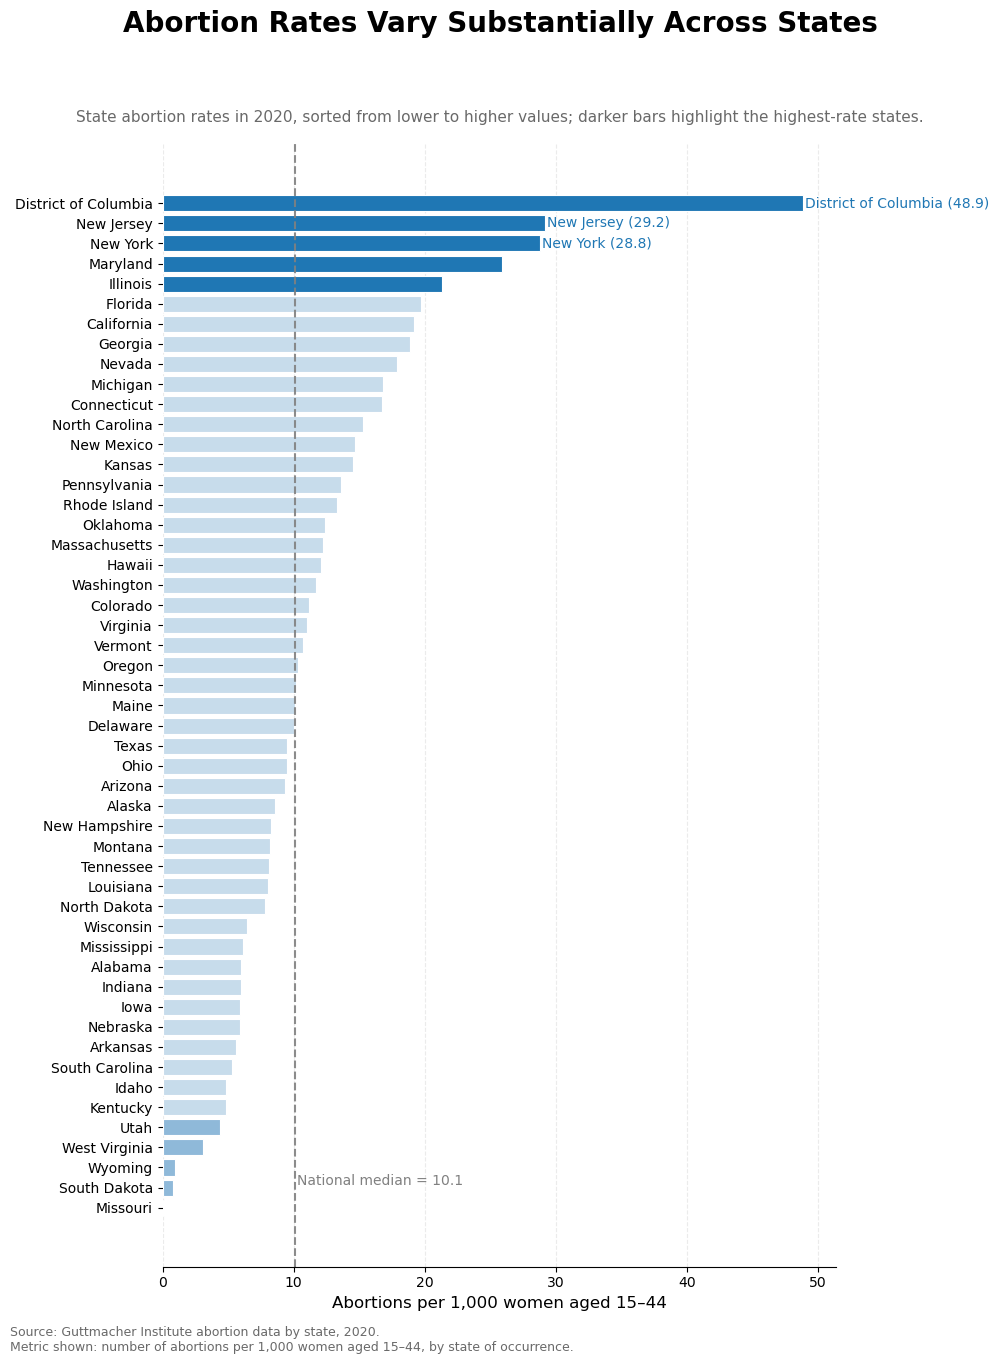

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------
# 1. Select and clean data
# -----------------------------
rate_col = 'No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020'
state_col = 'U.S. State'

plot_df = df[[state_col, rate_col]].copy()
plot_df = plot_df.rename(columns={
    state_col: 'state',
    rate_col: 'abortion_rate'
})

# convert to numeric just in case
plot_df['abortion_rate'] = pd.to_numeric(plot_df['abortion_rate'], errors='coerce')

# drop missing
plot_df = plot_df.dropna(subset=['abortion_rate'])

# sort for plotting
plot_df = plot_df.sort_values('abortion_rate', ascending=True).reset_index(drop=True)

# -----------------------------
# 2. Identify notable states
# -----------------------------
top_n = 5
bottom_n = 5

top_states = plot_df.nlargest(top_n, 'abortion_rate')['state'].tolist()
bottom_states = plot_df.nsmallest(bottom_n, 'abortion_rate')['state'].tolist()

national_median = plot_df['abortion_rate'].median()
national_mean = plot_df['abortion_rate'].mean()

# -----------------------------
# 3. Colors
# -----------------------------
base_color = '#c7dceb'        # light muted blue
highlight_top = '#1f77b4'     # darker blue for top states
highlight_bottom = '#8fb9d9'  # medium blue for lowest states

colors = []
for s in plot_df['state']:
    if s in top_states:
        colors.append(highlight_top)
    elif s in bottom_states:
        colors.append(highlight_bottom)
    else:
        colors.append(base_color)

# -----------------------------
# 4. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 14))

bars = ax.barh(
    plot_df['state'],
    plot_df['abortion_rate'],
    color=colors,
    edgecolor='white',
    linewidth=0.8
)

# median reference line
ax.axvline(
    national_median,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    alpha=0.9
)

# subtle x-grid only
ax.grid(axis='x', linestyle='--', alpha=0.25)
ax.set_axisbelow(True)

# labels
ax.set_xlabel('Abortions per 1,000 women aged 15–44', fontsize=12)
ax.set_ylabel('')

# title + subtitle
fig.suptitle(
    'Abortion Rates Vary Substantially Across States',
    fontsize=20,
    fontweight='bold',
    y=0.97
)

ax.set_title(
    'State abortion rates in 2020, sorted from lower to higher values; darker bars highlight the highest-rate states.',
    fontsize=11,
    color='dimgray',
    pad=16
)

# annotate median line
ax.text(
    national_median + 0.15,
    1,
    f'National median = {national_median:.1f}',
    color='gray',
    fontsize=10,
    va='bottom'
)

# annotate top 3 states
top3_df = plot_df.nlargest(3, 'abortion_rate').sort_values('abortion_rate')
for _, row in top3_df.iterrows():
    ax.text(
        row['abortion_rate'] + 0.15,
        plot_df.index[plot_df['state'] == row['state']][0],
        f"{row['state']} ({row['abortion_rate']:.1f})",
        fontsize=10,
        va='center',
        color=highlight_top
    )

# remove extra spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# make ticks a bit cleaner
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)

# x-limit with room for labels
ax.set_xlim(0, plot_df['abortion_rate'].max() + 2.5)

# source / note
fig.text(
    0.01, 0.01,
    'Source: Guttmacher Institute abortion data by state, 2020.\n'
    'Metric shown: number of abortions per 1,000 women aged 15–44, by state of occurrence.',
    ha='left',
    va='bottom',
    fontsize=9,
    color='dimgray'
)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

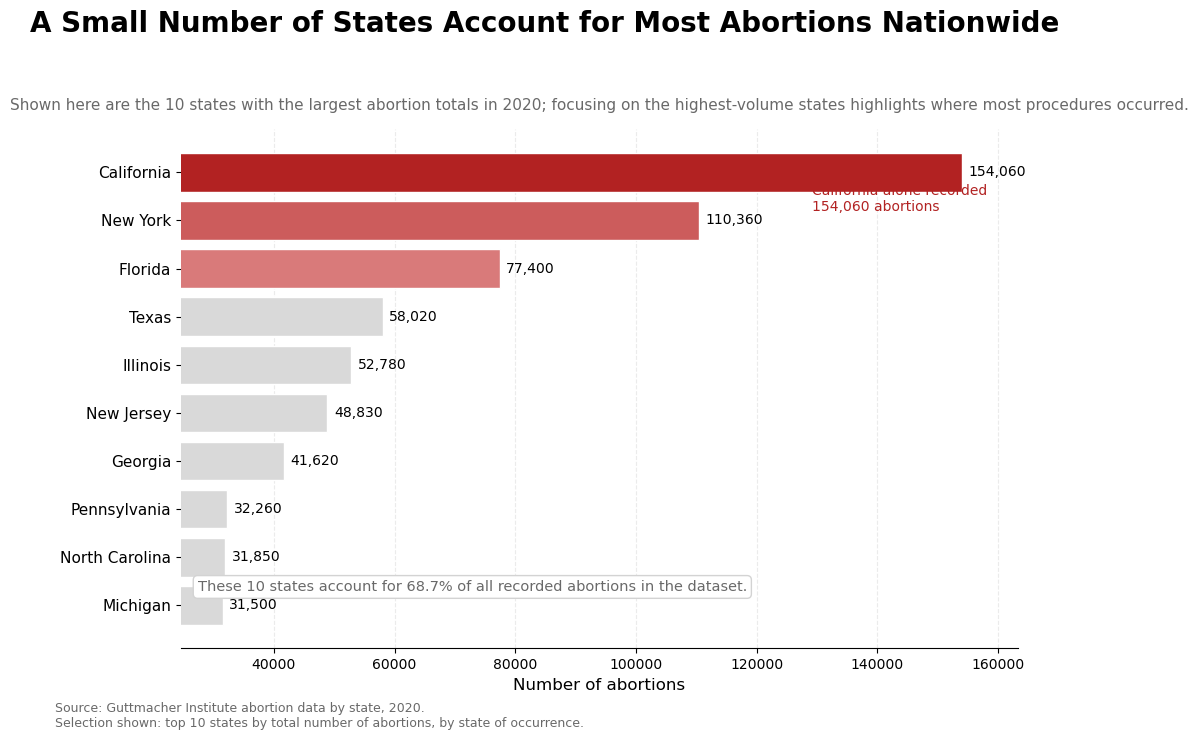

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Select and clean data
# -----------------------------
count_col = 'No. of abortions, by state of occurrence, 2020'
state_col = 'U.S. State'

plot_df2 = df[[state_col, count_col]].copy()
plot_df2 = plot_df2.rename(columns={
    state_col: 'state',
    count_col: 'abortions'
})

plot_df2['abortions'] = pd.to_numeric(plot_df2['abortions'], errors='coerce')
plot_df2 = plot_df2.dropna(subset=['abortions'])

# keep top 10 states only (intentional cherry-picking)
plot_df2 = plot_df2.sort_values('abortions', ascending=False).head(10).copy()

# reverse for barh so largest is on top visually
plot_df2 = plot_df2.sort_values('abortions', ascending=True).reset_index(drop=True)

# totals for annotation
top10_total = plot_df2['abortions'].sum()
overall_total = pd.to_numeric(df[count_col], errors='coerce').sum()
share_top10 = top10_total / overall_total * 100

# -----------------------------
# 2. Colors
# -----------------------------
base_color = '#d9d9d9'
highlight_color = '#b22222'   # firebrick
colors = [base_color] * len(plot_df2)
colors[-1] = highlight_color   # highest state
colors[-2] = '#cc5c5c'
colors[-3] = '#d97a7a'

# -----------------------------
# 3. Subtle deceptive scale
# -----------------------------
min_val = plot_df2['abortions'].min()
max_val = plot_df2['abortions'].max()

# start y-axis above zero to exaggerate differences, but not too aggressively
x_min = max(0, min_val * 0.78)
x_max = max_val * 1.06

# -----------------------------
# 4. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 7.5))

bars = ax.barh(
    plot_df2['state'],
    plot_df2['abortions'],
    color=colors,
    edgecolor='white',
    linewidth=1
)

# grid
ax.grid(axis='x', linestyle='--', alpha=0.25)
ax.set_axisbelow(True)

# titles
fig.suptitle(
    'A Small Number of States Account for Most Abortions Nationwide',
    fontsize=20,
    fontweight='bold',
    y=0.97
)

ax.set_title(
    'Shown here are the 10 states with the largest abortion totals in 2020; focusing on the highest-volume states highlights where most procedures occurred.',
    fontsize=11,
    color='dimgray',
    pad=14
)

# axis labels
ax.set_xlabel('Number of abortions', fontsize=12)
ax.set_ylabel('')

# deceptive axis range
ax.set_xlim(x_min, x_max)

# annotate all bars with values
for bar, value in zip(bars, plot_df2['abortions']):
    ax.text(
        value + (x_max - x_min) * 0.008,
        bar.get_y() + bar.get_height()/2,
        f'{int(value):,}',
        va='center',
        fontsize=10,
        color='black'
    )

# highlight biggest state with annotation
largest_row = plot_df2.iloc[-1]
ax.annotate(
    f"{largest_row['state']} alone recorded\n{int(largest_row['abortions']):,} abortions",
    xy=(largest_row['abortions'], len(plot_df2)-1),
    xytext=(largest_row['abortions'] - (x_max-x_min)*0.18, len(plot_df2)-1.8),
    arrowprops=dict(arrowstyle='->', color=highlight_color, lw=1.5),
    fontsize=10,
    color=highlight_color,
    ha='left'
)

# top 10 share annotation
ax.text(
    x_min + (x_max - x_min) * 0.02,
    0.3,
    f'These 10 states account for {share_top10:.1f}% of all recorded abortions in the dataset.',
    fontsize=10.5,
    color='dimgray',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray')
)

# style cleanup
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)

# source / note
fig.text(
    0.01, 0.01,
    'Source: Guttmacher Institute abortion data by state, 2020.\n'
    'Selection shown: top 10 states by total number of abortions, by state of occurrence.',
    ha='left',
    va='bottom',
    fontsize=9,
    color='dimgray'
)

plt.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.show()

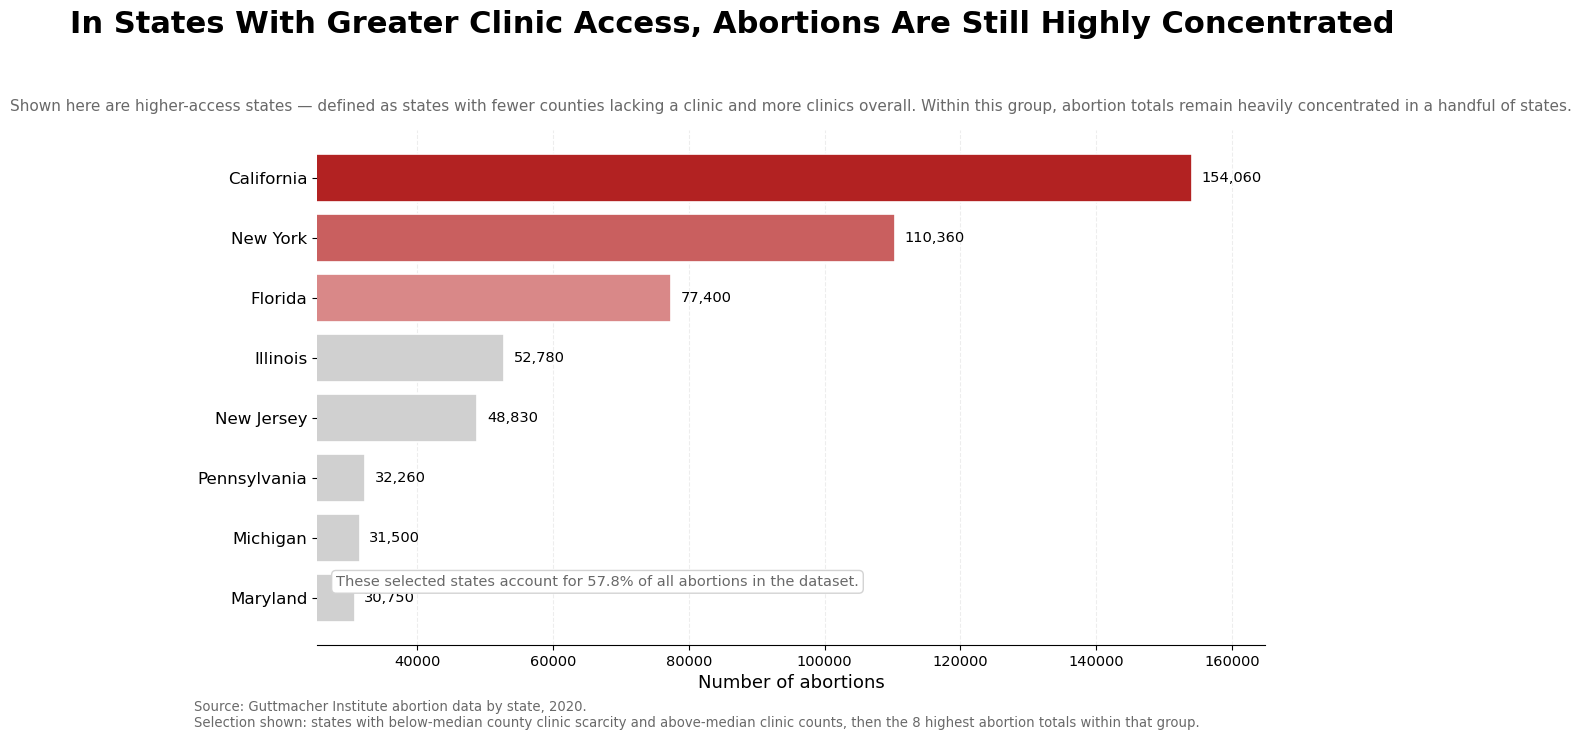

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Select columns
# -----------------------------
state_col = 'U.S. State'
count_col = 'No. of abortions, by state of occurrence, 2020'
clinic_gap_col = '% of counties without a known clinic, 2020'
clinic_num_col = 'No. of abortion clinics, 2020'

plot_df2 = df[[state_col, count_col, clinic_gap_col, clinic_num_col]].copy()
plot_df2 = plot_df2.rename(columns={
    state_col: 'state',
    count_col: 'abortions',
    clinic_gap_col: 'pct_counties_without_clinic',
    clinic_num_col: 'num_clinics'
})

for col in ['abortions', 'pct_counties_without_clinic', 'num_clinics']:
    plot_df2[col] = pd.to_numeric(plot_df2[col], errors='coerce')

plot_df2 = plot_df2.dropna(subset=['abortions', 'pct_counties_without_clinic', 'num_clinics'])

# -----------------------------
# 2. Cherry-pick a "reasonable" subset
# -----------------------------
# Define "higher-access" states as those with:
# - below-median share of counties without a clinic
# - above-median number of clinics
clinic_gap_median = plot_df2['pct_counties_without_clinic'].median()
clinic_num_median = plot_df2['num_clinics'].median()

subset_df = plot_df2[
    (plot_df2['pct_counties_without_clinic'] < clinic_gap_median) &
    (plot_df2['num_clinics'] > clinic_num_median)
].copy()

# Keep only the top 8 abortion-total states within this subset
subset_df = subset_df.sort_values('abortions', ascending=False).head(8).copy()

# Sort for barh
subset_df = subset_df.sort_values('abortions', ascending=True).reset_index(drop=True)

# -----------------------------
# 3. Summary stats for annotations
# -----------------------------
subset_total = subset_df['abortions'].sum()
overall_total = pd.to_numeric(df[count_col], errors='coerce').sum()
subset_share = subset_total / overall_total * 100

largest_row = subset_df.iloc[-1]

# -----------------------------
# 4. More deceptive visual design
# -----------------------------
colors = ['#d0d0d0'] * len(subset_df)
if len(subset_df) >= 3:
    colors[-3] = '#d98888'
    colors[-2] = '#c95f5f'
    colors[-1] = '#b22222'

# Truncated baseline to exaggerate differences
min_val = subset_df['abortions'].min()
max_val = subset_df['abortions'].max()
x_min = min_val * 0.82
x_max = max_val * 1.07

# -----------------------------
# 5. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 7.5))

bars = ax.barh(
    subset_df['state'],
    subset_df['abortions'],
    color=colors,
    edgecolor='white',
    linewidth=1.2
)

ax.set_xlim(x_min, x_max)
ax.grid(axis='x', linestyle='--', alpha=0.22)
ax.set_axisbelow(True)

fig.suptitle(
    'In States With Greater Clinic Access, Abortions Are Still Highly Concentrated',
    fontsize=22,
    fontweight='bold',
    y=0.97
)

ax.set_title(
    'Shown here are higher-access states — defined as states with fewer counties lacking a clinic and more clinics overall. '
    'Within this group, abortion totals remain heavily concentrated in a handful of states.',
    fontsize=11,
    color='dimgray',
    pad=14
)

ax.set_xlabel('Number of abortions', fontsize=13)
ax.set_ylabel('')

# value labels
for bar, value in zip(bars, subset_df['abortions']):
    ax.text(
        value + (x_max - x_min) * 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{int(value):,}',
        va='center',
        fontsize=10.5,
        color='black'
    )

# dominant-state annotation
ax.annotate(
    f"{largest_row['state']} alone recorded\n{int(largest_row['abortions']):,} abortions",
    xy=(largest_row['abortions'], len(subset_df)-1),
    xytext=(largest_row['abortions'] - (x_max - x_min) * 0.22, len(subset_df)-1.2),
    arrowprops=dict(arrowstyle='->', color='#b22222', lw=1.5),
    fontsize=10.5,
    color='#b22222',
    ha='left'
)

# concentration annotation
ax.text(
    x_min + (x_max - x_min) * 0.02,
    0.2,
    f'These selected states account for {subset_share:.1f}% of all abortions in the dataset.',
    fontsize=10.5,
    color='dimgray',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray')
)

# style cleanup
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=10.5)

fig.text(
    0.01, 0.01,
    'Source: Guttmacher Institute abortion data by state, 2020.\n'
    'Selection shown: states with below-median county clinic scarcity and above-median clinic counts, '
    'then the 8 highest abortion totals within that group.',
    ha='left',
    va='bottom',
    fontsize=9.5,
    color='dimgray'
)

plt.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.show()

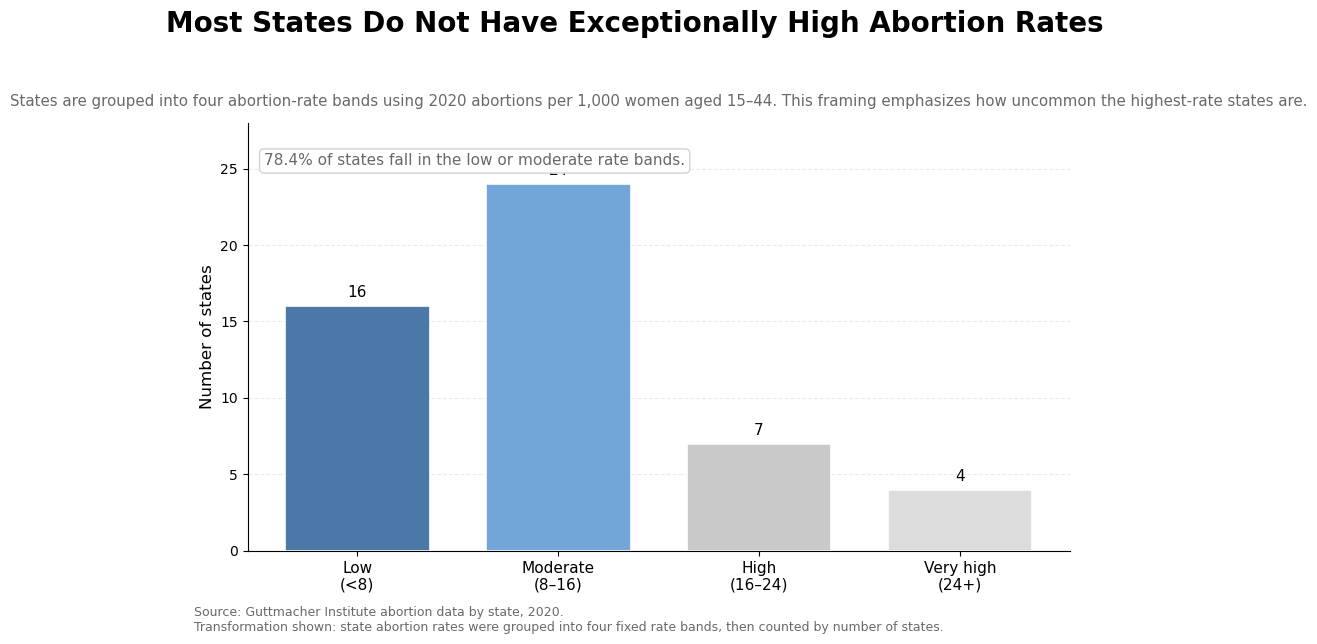

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Select and clean data
# -----------------------------
rate_col = 'No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020'
state_col = 'U.S. State'

plot_df2 = df[[state_col, rate_col]].copy()
plot_df2 = plot_df2.rename(columns={
    state_col: 'state',
    rate_col: 'abortion_rate'
})

plot_df2['abortion_rate'] = pd.to_numeric(plot_df2['abortion_rate'], errors='coerce')
plot_df2 = plot_df2.dropna(subset=['abortion_rate']).copy()

# optional: remove DC if you think it makes the first chart too extreme,
# but keeping it is also fine. Here we keep it.

# -----------------------------
# 2. Bin the rates
# -----------------------------
# fixed bins chosen to make "most states are low/moderate" read clearly
bins = [0, 8, 16, 24, 60]
labels = ['Low\n(<8)', 'Moderate\n(8–16)', 'High\n(16–24)', 'Very high\n(24+)']

plot_df2['rate_band'] = pd.cut(
    plot_df2['abortion_rate'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

count_df = (
    plot_df2['rate_band']
    .value_counts(sort=False)
    .reset_index()
)

count_df.columns = ['rate_band', 'num_states']

total_states = count_df['num_states'].sum()
low_mod_share = (
    count_df.loc[count_df['rate_band'].isin(['Low\n(<8)', 'Moderate\n(8–16)']), 'num_states'].sum()
    / total_states * 100
)

# -----------------------------
# 3. Colors
# -----------------------------
colors = ['#4c78a8', '#72a6d9', '#c9c9c9', '#dcdcdc']

# -----------------------------
# 4. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 6.5))

bars = ax.bar(
    count_df['rate_band'],
    count_df['num_states'],
    color=colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.72
)

ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.set_axisbelow(True)

fig.suptitle(
    'Most States Do Not Have Exceptionally High Abortion Rates',
    fontsize=20,
    fontweight='bold',
    y=0.97
)

ax.set_title(
    'States are grouped into four abortion-rate bands using 2020 abortions per 1,000 women aged 15–44. '
    'This framing emphasizes how uncommon the highest-rate states are.',
    fontsize=10.8,
    color='dimgray',
    pad=12
)

ax.set_xlabel('')
ax.set_ylabel('Number of states', fontsize=12)

# value labels
for bar, value in zip(bars, count_df['num_states']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.4,
        f'{int(value)}',
        ha='center',
        va='bottom',
        fontsize=11
    )

# annotation
ax.text(
    0.02, 0.90,
    f'{low_mod_share:.1f}% of states fall in the low or moderate rate bands.',
    transform=ax.transAxes,
    fontsize=11,
    color='dimgray',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray')
)

# subtle y limit
ax.set_ylim(0, count_df['num_states'].max() + 4)

# clean up
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10)

fig.text(
    0.01, 0.01,
    'Source: Guttmacher Institute abortion data by state, 2020.\n'
    'Transformation shown: state abortion rates were grouped into four fixed rate bands, then counted by number of states.',
    ha='left',
    va='bottom',
    fontsize=9,
    color='dimgray'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.show()

In [11]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. 选列
# -----------------------------
state_col = 'U.S. State'
provider_col = 'No. of abortion providers, 2017'
rate_col = 'No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020'

df_plot = df[[state_col, provider_col, rate_col]].copy()

df_plot = df_plot.rename(columns={
    state_col: 'state',
    provider_col: 'providers',
    rate_col: 'rate'
})

# 转 numeric
df_plot['providers'] = pd.to_numeric(df_plot['providers'], errors='coerce')
df_plot['rate'] = pd.to_numeric(df_plot['rate'], errors='coerce')

df_plot = df_plot.dropna()

# -----------------------------
# 2. 分 bin（关键 transformation）
# -----------------------------
df_plot['provider_bin'] = pd.qcut(
    df_plot['providers'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

# -----------------------------
# 3. 计算 mean rate（用于图1）
# -----------------------------
group_df = (
    df_plot
    .groupby('provider_bin')
    .agg(mean_rate=('rate', 'mean'))
    .reset_index()
)

print(group_df)

  provider_bin  mean_rate
0          Low   6.000000
1   Medium-Low  11.880000
2  Medium-High  11.380000
3         High  17.692308


C:\Users\yhy_s\AppData\Local\Temp\ipykernel_9420\2251606125.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('provider_bin')


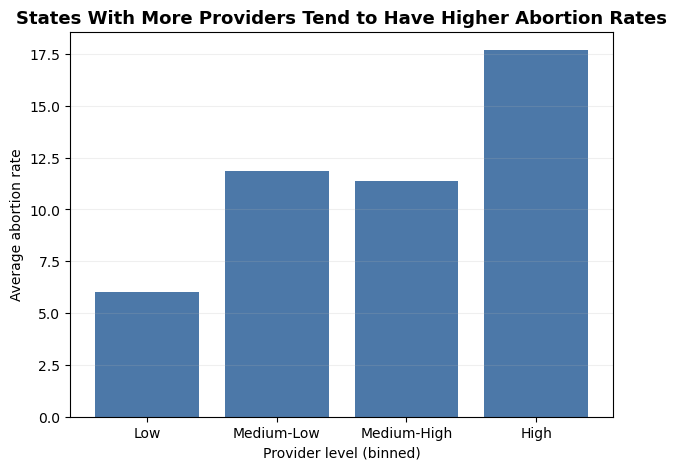

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    group_df['provider_bin'],
    group_df['mean_rate'],
    color='#4c78a8'
)

plt.title(
    'States With More Providers Tend to Have Higher Abortion Rates',
    fontsize=13, weight='bold'
)

plt.xlabel('Provider level (binned)')
plt.ylabel('Average abortion rate')

plt.grid(axis='y', alpha=0.2)

plt.show()

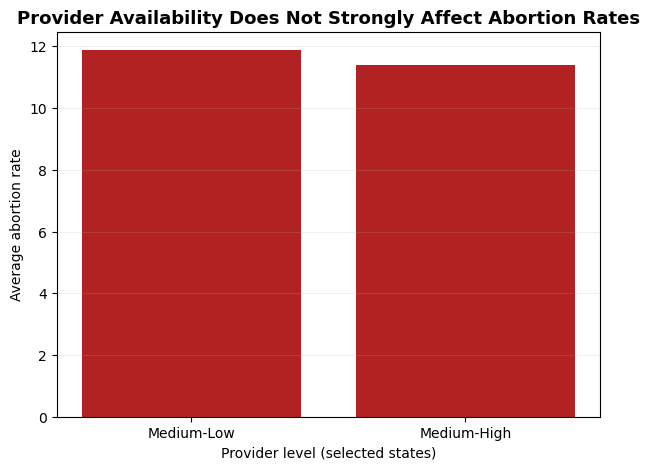

In [13]:
# 只选中间两组（故意）
deceptive_df = group_df[
    group_df['provider_bin'].isin(['Medium-Low', 'Medium-High'])
]

plt.figure(figsize=(7,5))

plt.bar(
    deceptive_df['provider_bin'],
    deceptive_df['mean_rate'],
    color='#b22222'
)

plt.title(
    'Provider Availability Does Not Strongly Affect Abortion Rates',
    fontsize=13, weight='bold'
)

plt.xlabel('Provider level (selected states)')
plt.ylabel('Average abortion rate')

plt.grid(axis='y', alpha=0.2)

plt.show()